# 6.6 Q3: Customer Churn Prediction

**Objective:** Predict customer churn using synthetic data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
import os

# Use THIS notebook's folder paths
NOTEBOOK_DIR = os.getcwd()
DATASETS_DIR = os.path.join(NOTEBOOK_DIR, 'datasets')
OUTPUTS_DIR = os.path.join(NOTEBOOK_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [2]:
# Generate Synthetic Dataset
np.random.seed(42)
n = 500

data = {
    'age': np.random.randint(18, 70, n),
    'monthly_charges': np.random.uniform(30, 120, n),
    'tenure': np.random.randint(1, 72, n),
    'total_services': np.random.randint(1, 6, n)
}

churn_prob = 1 / (1 + np.exp(-(0.05*data['age'] - 0.08*data['monthly_charges'] + 0.03*data['tenure'] + 0.4*data['total_services'] - 2)))
data['churn'] = (np.random.random(n) < churn_prob).astype(int)

df = pd.DataFrame(data)
print(f"Churn Rate: {df['churn'].mean()*100:.1f}%")
print(df.head())

Churn Rate: 14.2%
   age  monthly_charges  tenure  total_services  churn
0   56       115.937875      25               3      0
1   69        96.410723      38               5      0
2   46        79.891865       2               1      0
3   32        85.054867       7               1      0
4   60        67.764006      34               4      0


In [3]:
# Train Model
X = df.drop('churn', axis=1).values
y = df['churn'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

Accuracy: 0.9000

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        87
           1       0.62      0.62      0.62        13

    accuracy                           0.90       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.90      0.90      0.90       100



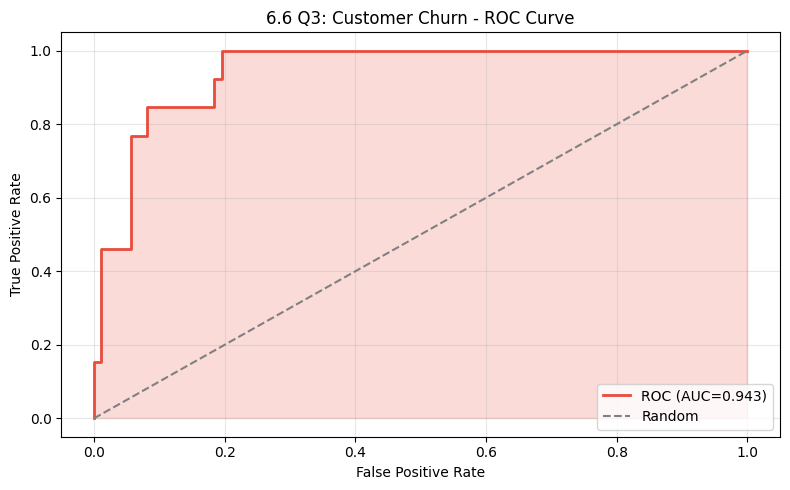

✅ Saved to: /home/z/my-project/ML-Labs-1-2-Final/02-Logistic-Regression/outputs/6.6_Q3_Customer_Churn_Prediction.png


In [4]:
# ROC Curve - Save to outputs/
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'ROC (AUC={roc_auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random')
plt.fill_between(fpr, tpr, alpha=0.2, color='#e74c3c')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('6.6 Q3: Customer Churn - ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, '6.6_Q3_Customer_Churn_Prediction.png'), dpi=120)
plt.show()
print(f"✅ Saved to: {OUTPUTS_DIR}/6.6_Q3_Customer_Churn_Prediction.png")